# 04 - Results Comparison
Compare validation curves, computational efficiency, and held-out test accuracy for ACE vs MACE.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    ace_df = pd.read_csv("../data/ace_metrics.csv")
    mace_df = pd.read_csv("../data/mace_metrics.csv")
    ace_test_df = pd.read_csv("../data/ace_test_metrics.csv")
    mace_test_df = pd.read_csv("../data/mace_test_metrics.csv")
except FileNotFoundError:
    print("Please run Notebooks 02 and 03 first to generate train/val and test metrics!")
    raise


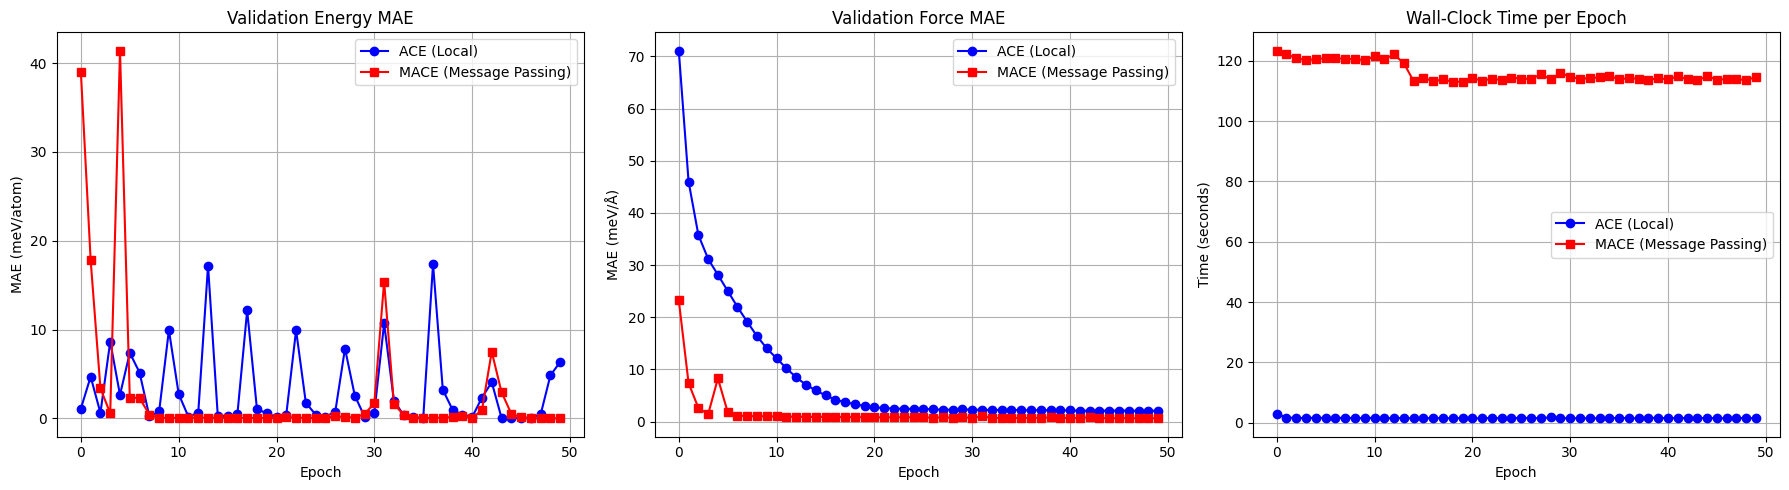

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Energy MAE
axes[0].plot(ace_df["epoch"], ace_df["val_e_mae"], label="ACE (Local)", color='blue', marker='o')
axes[0].plot(mace_df["epoch"], mace_df["val_e_mae"], label="MACE (Message Passing)", color='red', marker='s')
axes[0].set_title("Validation Energy MAE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE (meV/atom)")
axes[0].legend()
axes[0].grid(True)

# Plot Force MAE
axes[1].plot(ace_df["epoch"], ace_df["val_f_mae"], label="ACE (Local)", color='blue', marker='o')
axes[1].plot(mace_df["epoch"], mace_df["val_f_mae"], label="MACE (Message Passing)", color='red', marker='s')
axes[1].set_title("Validation Force MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (meV/Å)")
axes[1].legend()
axes[1].grid(True)

# Plot Training Time per Epoch
axes[2].plot(ace_df["epoch"], ace_df["time"], label="ACE (Local)", color='blue', marker='o')
axes[2].plot(mace_df["epoch"], mace_df["time"], label="MACE (Message Passing)", color='red', marker='s')
axes[2].set_title("Wall-Clock Time per Epoch")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Time (seconds)")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Summary Table
summary = pd.DataFrame({
    "Model": ["ACE", "MACE"],
    "Best Val Energy MAE (meV/at)": [ace_df["val_e_mae"].min(), mace_df["val_e_mae"].min()],
    "Best Val Force MAE (meV/A)": [ace_df["val_f_mae"].min(), mace_df["val_f_mae"].min()],
    "Test Energy MAE (meV/at)": [ace_test_df["test_e_mae"].iloc[0], mace_test_df["test_e_mae"].iloc[0]],
    "Test Force MAE (meV/A)": [ace_test_df["test_f_mae"].iloc[0], mace_test_df["test_f_mae"].iloc[0]],
    "Avg Time per Epoch (s)": [ace_df["time"].mean(), mace_df["time"].mean()],
    "Total Epochs": [len(ace_df), len(mace_df)],
    "Total Training Time (s)": [ace_df["time"].sum(), mace_df["time"].sum()]
})
summary

,Model,Best Val Energy MAE (meV/at),Best Val Force MAE (meV/A),Avg Time per Epoch (s),Total Epochs to Converge,Total Training Time (s)
0,ACE,0.040415,2.049161,1.599840,50,79.991990
1,MACE,0.005317,0.617657,116.010528,50,5800.526403
